In [1]:
import json
import pymysql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pymongo import MongoClient

In [2]:
def get_local():
    with open("../auth.json", "r") as f:
        auth = json.load(f)["local"]
        uri = f'mongodb://{auth["username"]}:{auth["password"]}@{auth["host"]}:{auth["port"]}/{auth["database"]}'
        conn = MongoClient(uri)[auth["database"]]
    return conn

def get_remote():
    with open("../auth.json", "r") as f:
        auth = json.load(f)["remote"]
        conn = pymysql.connect(
            host=auth["host"], port=auth["port"], user=auth["username"], password=auth["password"],
            database=auth["database"], charset=auth["charset"], cursorclass=pymysql.cursors.DictCursor
       )
    return conn

In [3]:
remote = get_remote()

### Mpm310

In [41]:
sql = f'SELECT * FROM mpm310_sang WHERE farmid = "0005" AND rcvtime >= "20260530000000" ORDER BY rcvtime ASC;'

In [42]:
with remote.cursor() as cursor:
    cursor.execute(sql)
    results = cursor.fetchall()

In [43]:
mpm310 = pd.DataFrame(list(results))
mpm310.head()

,devid,rcvtime,farmid,voltage,current,activepower,reactivepower,apparentpower,frequency,powerfactor,actelectric,reaelectric,peakactive,peakcurrent
0,2,20260530000049,0005,229.37,0.00,0.00,0.00,0.00,59.9,0.00,7,1,4.284,19.956
1,4,20260530000051,0005,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0,0,1.653,5.018
2,5,20260530000052,0005,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0,0,1.102,5.004
3,6,20260530000053,0005,229.49,0.00,0.00,0.00,0.00,60.0,0.00,0,0,1.100,5.005
4,7,20260530000054,0005,230.73,0.00,0.00,0.00,0.00,59.9,0.00,0,0,1.101,5.006


In [44]:
mpm310["rcv_dt"] = pd.to_datetime(
    mpm310["rcvtime"].astype(str),
    format="%Y%m%d%H%M%S"
)
df_310 = mpm310[["rcv_dt", "activepower", "devid"]].copy()
df_310["rcv_h"] = df_310["rcv_dt"].dt.strftime("%Y%m%d-%H")
df_310["activepower_60"] = df_310["activepower"] / 60
df_310

,rcv_dt,activepower,devid,rcv_h,activepower_60
0,2026-05-30 00:00:49,0.00,2,20260530-00,0.00
1,2026-05-30 00:00:51,0.00,4,20260530-00,0.00
2,2026-05-30 00:00:52,0.00,5,20260530-00,0.00
3,2026-05-30 00:00:53,0.00,6,20260530-00,0.00
4,2026-05-30 00:00:54,0.00,7,20260530-00,0.00
...,...,...,...,...,...
94890,2026-06-08 10:02:58,0.00,7,20260608-10,0.00
94891,2026-06-08 10:02:59,0.00,8,20260608-10,0.00
94892,2026-06-08 10:03:02,0.00,2,20260608-10,0.00
94893,2026-06-08 10:03:03,0.00,3,20260608-10,0.00


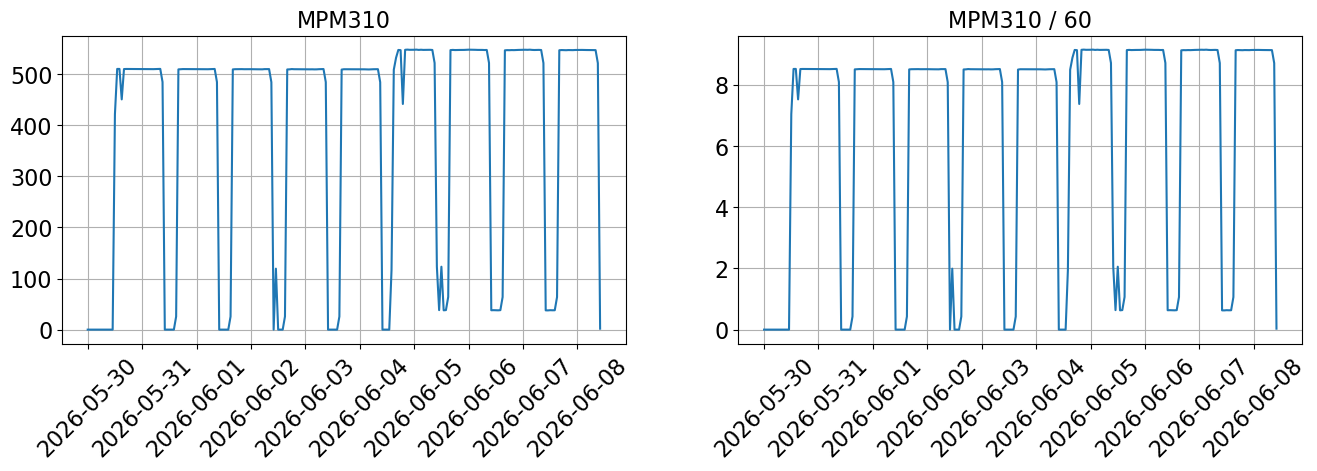

In [46]:
agg_310 = df_310.groupby("rcv_h")[["activepower", "activepower_60"]].sum()

dates = pd.to_datetime(agg_310.index, format="%Y%m%d-%H")

plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.plot(dates, agg_310["activepower"].values)
plt.xticks(fontsize=16, rotation=45)
plt.yticks(fontsize=16)
plt.grid(True)
plt.title("MPM310", fontsize=16)

plt.subplot(1, 2, 2)
plt.plot(dates, agg_310["activepower_60"].values)
plt.xticks(fontsize=16, rotation=45)
plt.yticks(fontsize=16)
plt.grid(True)
plt.title("MPM310 / 60", fontsize=16)

plt.show()

### Mpm330

In [47]:
sql = f'SELECT * FROM mpm330_sang WHERE farmid = "0005" AND rcvtime >= "20260530000000" ORDER BY rcvtime ASC;'

In [48]:
with remote.cursor() as cursor:
    cursor.execute(sql)
    results = cursor.fetchall()

In [49]:
mpm330 = pd.DataFrame(list(results))
mpm330

,devid,rcvtime,farmid,rsvoltage,stvoltage,trvoltage,rvoltage,svoltage,tvoltage,rcurrent,...,tacpower,rrepower,srepower,trepower,rappower,sappower,tappower,rpowerfactor,spowerfactor,tpowerfactor
0,0,20260530000058,0005,397.82,396.92,396.84,229.64,229.73,228.61,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00,441.95
1,0,20260530000155,0005,397.80,396.86,397.04,229.78,229.58,228.69,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00,129.04
2,0,20260530000251,0005,397.80,397.00,397.24,229.81,229.54,228.90,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00,268.17
3,0,20260530000357,0005,398.18,397.38,397.38,229.89,229.91,228.97,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00,236.01
4,0,20260530000452,0005,398.08,397.38,397.26,229.77,229.92,228.96,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00,318.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13552,0,20260608095955,0005,389.32,388.52,388.68,224.87,224.69,223.96,10.320,...,3.680,-0.400,0.000,-0.640,2.274,0.000,3.734,654.38,0.00,225.14
13553,0,20260608100051,0005,389.42,388.68,388.90,224.98,224.71,224.11,10.320,...,3.680,-0.400,0.000,-0.640,2.274,0.000,3.734,654.38,0.00,211.64
13554,0,20260608100156,0005,389.52,388.74,388.94,225.01,224.78,224.12,10.320,...,3.680,-0.400,0.000,-0.640,2.274,0.000,3.734,654.38,0.00,626.74
13555,0,20260608100252,0005,389.18,388.70,388.78,224.74,224.67,224.19,10.320,...,3.680,-0.400,0.000,-0.640,2.274,0.000,3.734,654.38,0.00,107.74


In [50]:
mpm330["rcv_dt"] = pd.to_datetime(
    mpm330["rcvtime"].astype(str),
    format="%Y%m%d%H%M%S"
)
df_330 = mpm330[["rcv_dt", "totalacpower", "devid"]].copy()
df_330["rcv_h"] = df_330["rcv_dt"].dt.strftime("%Y%m%d-%H")
df_330["activepower_60"] = df_330["totalacpower"] / 60
df_330

,rcv_dt,totalacpower,devid,rcv_h,activepower_60
0,2026-05-30 00:00:58,0.000,0,20260530-00,0.000
1,2026-05-30 00:01:55,0.000,0,20260530-00,0.000
2,2026-05-30 00:02:51,0.000,0,20260530-00,0.000
3,2026-05-30 00:03:57,0.000,0,20260530-00,0.000
4,2026-05-30 00:04:52,0.000,0,20260530-00,0.000
...,...,...,...,...,...
13552,2026-06-08 09:59:55,6.000,0,20260608-09,0.100
13553,2026-06-08 10:00:51,6.000,0,20260608-10,0.100
13554,2026-06-08 10:01:56,6.000,0,20260608-10,0.100
13555,2026-06-08 10:02:52,6.000,0,20260608-10,0.100


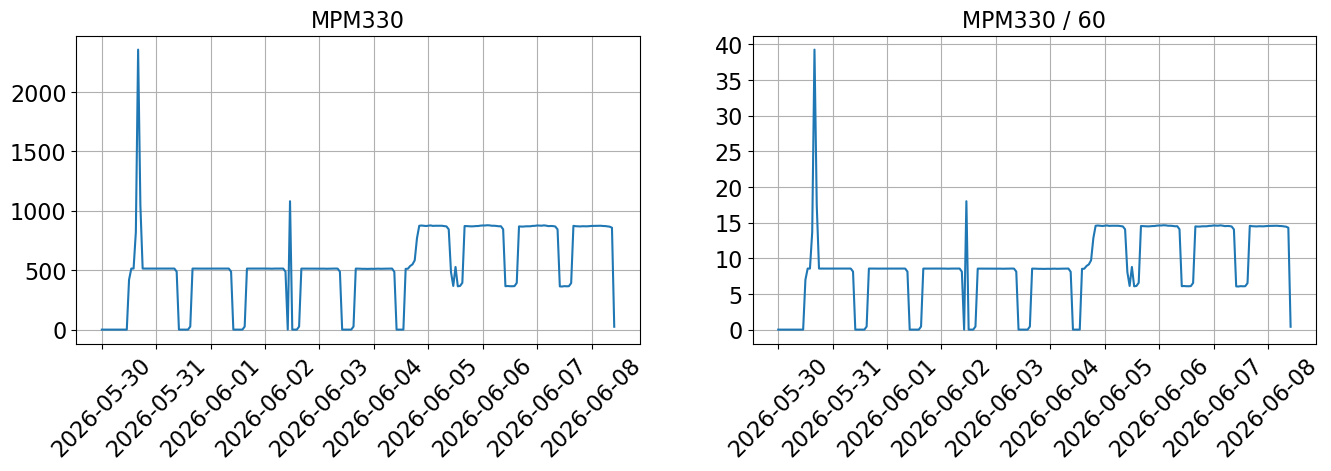

In [51]:
agg_330 = df_330.groupby("rcv_h")[["totalacpower", "activepower_60"]].sum()

dates = pd.to_datetime(agg_330.index, format="%Y%m%d-%H")

plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.plot(dates, agg_330["totalacpower"].values)
plt.xticks(fontsize=16, rotation=45)
plt.yticks(fontsize=16)
plt.title("MPM330", fontsize=16)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(dates, agg_330["activepower_60"].values)
plt.title("MPM330 / 60", fontsize=16)
plt.xticks(fontsize=16, rotation=45)
plt.yticks(fontsize=16)
plt.grid(True)

plt.show()

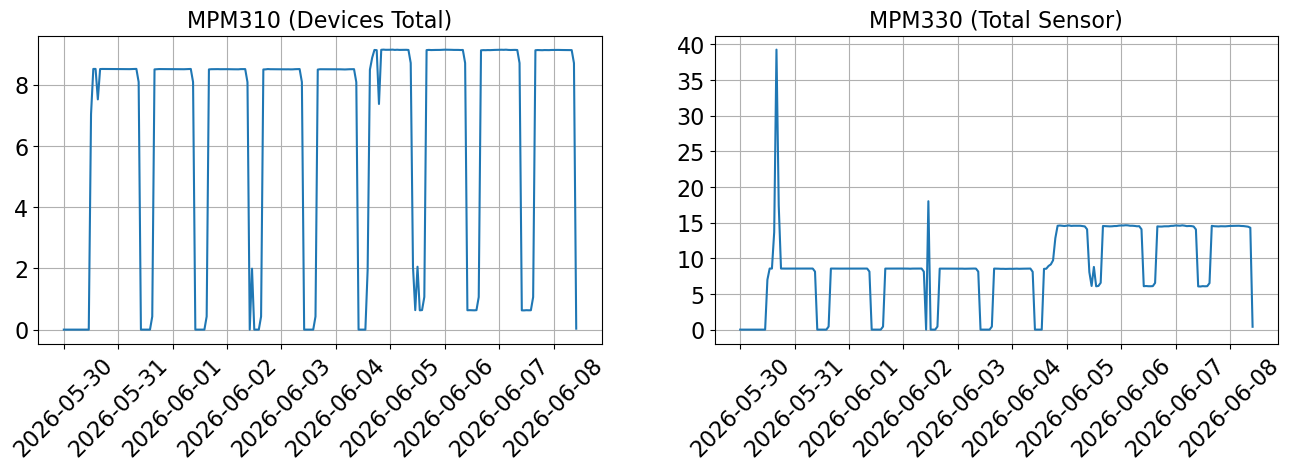

In [55]:
agg_330 = df_330.groupby("rcv_h")[["totalacpower", "activepower_60"]].sum()

dates = pd.to_datetime(agg_330.index, format="%Y%m%d-%H")

plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.plot(dates, agg_310["activepower_60"].values)
plt.xticks(fontsize=16, rotation=45)
plt.yticks(fontsize=16)
plt.title("MPM310 (Devices Total)", fontsize=16)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(dates, agg_330["activepower_60"].values)
plt.title("MPM330 (Total Sensor)", fontsize=16)
plt.xticks(fontsize=16, rotation=45)
plt.yticks(fontsize=16)
plt.grid(True)

plt.show()

In [59]:
agg_330["totalacpower_60"].round(2)

KeyError: 'totalacpower_60'